# F1 — Teams / Constructors (1950–2024)

Constructor-level analyses across the full history of F1.
This notebook covers **Section 4** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 4.1 | Champion team by wins per season |
| 4.2 | Champion team by wins per race (all-time) |
| 4.3 | Top 10 teams by pole positions (1950–2024) |
| 4.4 | Top 5 winners inside each of the top 10 teams |
| 4.5 | Top 10 teams by total number of drivers |
| 4.6 | Top 5 teams that led the constructor standings wire-to-wire |
| 4.7 | Constructor with longest consecutive race-win streak |
| 4.8 | Biggest year-over-year improvement in constructor standings |
| 4.9 | Constructors that never scored a podium |
| 4.10 | Top 10 teams — most total race entries |
| 4.11 | Top 10 teams — fewest total race entries |
| 4.12 | Head-to-head teammate record (most competitive pairs) |
| 4.13 | Head-to-head teammate record (least competitive pairs) |

## Setup — imports and data loading

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers               = pd.read_csv('excel/drivers.csv')
results               = pd.read_csv('excel/results.csv')
races                 = pd.read_csv('excel/races.csv')
constructors          = pd.read_csv('excel/constructors.csv')
qualifying            = pd.read_csv('excel/qualifying.csv')
constructor_standings = pd.read_csv('excel/constructor_standings.csv')

drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

# constructors.name is 'Mercedes', 'McLaren', etc. — promote it to a 'team' column
# so every chart can do .merge(constructors[['constructorId', 'team']], ...)
constructors = constructors.rename(columns={'name': 'team'})

print('drivers              :', drivers.shape)
print('results              :', results.shape)
print('races                :', races.shape)
print('constructors         :', constructors.shape)
print('qualifying           :', qualifying.shape)
print('constructor_standings:', constructor_standings.shape)

drivers              : (861, 10)
results              : (26759, 18)
races                : (1125, 18)
constructors         : (212, 5)
qualifying           : (10494, 9)
constructor_standings: (13391, 7)


## Data cleanup — Indianapolis 500 (1950–1960)

Same cleanup as the other notebooks: strip Indy 500 rows so per-team statistics aren't polluted by drivers/teams who never raced anywhere else.

In [113]:
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False),
    'raceId'
]
n_before_results = len(results)

results               = results              [~results              ['raceId'].isin(indy_race_ids)].copy()
qualifying            = qualifying           [~qualifying           ['raceId'].isin(indy_race_ids)].copy()
constructor_standings = constructor_standings[~constructor_standings['raceId'].isin(indy_race_ids)].copy()
races                 = races                [~races                ['raceId'].isin(indy_race_ids)].copy()

print(f'Indy 500 races removed   : {len(indy_race_ids)}')
print(f'Result rows dropped      : {n_before_results - len(results):,}')
print(f'Clean dataset:')
print(f'  races                : {len(races):,}')
print(f'  results              : {len(results):,}')
print(f'  qualifying           : {len(qualifying):,}')
print(f'  constructor_standings: {len(constructor_standings):,}')

Indy 500 races removed   : 11
Result rows dropped      : 405
Clean dataset:
  races                : 1,114
  results              : 26,354
  qualifying           : 10,494
  constructor_standings: 13,365


## Shared helpers — team colors, decade colors, etc.

Per-team colors approximate each constructor's livery (Ferrari red, McLaren orange, Mercedes silver, etc.). Teams not in the dict fall back to neutral gray.

In [114]:
# Team livery colors - covers the most prominent teams.
# Fallback for unknown teams: neutral gray.
TEAM_COLORS = {
    'Ferrari':         '#DC0000',
    'McLaren':         '#FF8700',
    'Mercedes':        '#888888',
    'Williams':        '#0099FF',
    'Red Bull':        '#1E41FF',
    'Renault':         '#FFD700',
    'Lotus F1':        '#FFB800',
    'Team Lotus':      '#1B5E20',
    'Brabham':         '#FFC107',
    'Tyrrell':         '#1F4E79',
    'Cooper':          '#FFA500',
    'BRM':             '#006400',
    'Maserati':        '#003366',
    'Vanwall':         '#1B4D3E',
    'Brawn':           '#80FF00',
    'Honda':           '#E60012',
    'Toyota':          '#EB0A1E',
    'BMW Sauber':      '#003BFF',
    'Benetton':        '#0066CC',
    'Jordan':          '#FFB300',
    'Alfa Romeo':      '#A52A2A',
    'Stewart':         '#003366',
    'Sauber':          '#52E252',
    'Force India':     '#FF80C7',
    'Racing Point':    '#F596C8',
    'Aston Martin':    '#006F62',
    'Alpine F1 Team':  '#0090FF',
    'AlphaTauri':      '#2B4562',
    'Toro Rosso':      '#475F8B',
    'Minardi':         '#000000',
    'Arrows':          '#FFA500',
    'Prost':           '#003366',
    'Wolf':            '#222222',
    'Ligier':          '#0099FF',
    'March':           '#5B2A86',
    'Matra':           '#0066CC',
    'Shadow':          '#222222',
    'Hesketh':         '#FF1493',
    'Surtees':         '#DC0000',
    'Lancia':          '#8B4513',
    'Lotus':           '#1B5E20',
    'Haas F1 Team':    '#9C9C9C',
}


def team_color(team):
    """Return livery color for `team`, falling back to gray for unknowns."""
    return TEAM_COLORS.get(team, '#999999')


# Pre-computed lookup: every constructor's active span in F1.
# Used by 4.2 / 4.3 / 4.5 / 4.10 / 4.11 to annotate "Ferrari (1950-2024, 75 yrs)"
# alongside the headline number.
team_activity = (
    results.merge(races[['raceId', 'year']], on='raceId')
           .merge(constructors[['constructorId', 'team']], on='constructorId')
           .groupby('team')['year']
           .agg(first_year='min', last_year='max', seasons='nunique')
           .reset_index())


def team_span_label(team):
    """Return 'YYYY-YYYY, N yrs' for a given team, or '' if unknown."""
    row = team_activity[team_activity['team'] == team]
    if row.empty:
        return ''
    fy = int(row['first_year'].iloc[0])
    ly = int(row['last_year'].iloc[0])
    seasons = int(row['seasons'].iloc[0])
    span = f'{fy}' if fy == ly else f'{fy}-{ly}'
    return f'{span}, {seasons} yrs'


---
# Section 4 — Teams / Constructors

### Chart 4.1 — Top winning team per season (1950–2024)

For every year in F1 history, identify the constructor with the **most race wins** in that season. Plotted as a vertical timeline so you can see which teams dominated which eras at a glance.

75 seasons covered.

 year          team  wins
 1950    Alfa Romeo     6
 1951    Alfa Romeo     5
 1952       Ferrari     7
 1953       Ferrari     7
 1954      Mercedes     4
 1955      Mercedes     5
 1956       Ferrari     6
 1957      Maserati     4
 1958       Vanwall     6
 1959 Cooper-Climax     5
 1960 Cooper-Climax     6
 1961       Ferrari     5
 1962           BRM     4
 1963  Lotus-Climax     7
 1964       Ferrari     3
 1965  Lotus-Climax     6
 1966 Brabham-Repco     4
 1967 Brabham-Repco     4
 1968    Lotus-Ford     5
 1969    Matra-Ford     6
 1970    Team Lotus     6
 1971       Tyrrell     7
 1972    Team Lotus     5
 1973    Team Lotus     7
 1974       McLaren     4
 1975       Ferrari     6
 1976       Ferrari     6
 1977    Team Lotus     5
 1978    Team Lotus     8
 1979       Ferrari     6
 1980      Williams     6
 1981      Williams     4
 1982       McLaren     4
 1983       Brabham     4
 1984       McLaren    12
 1985       McLaren     6
 1986      Willia

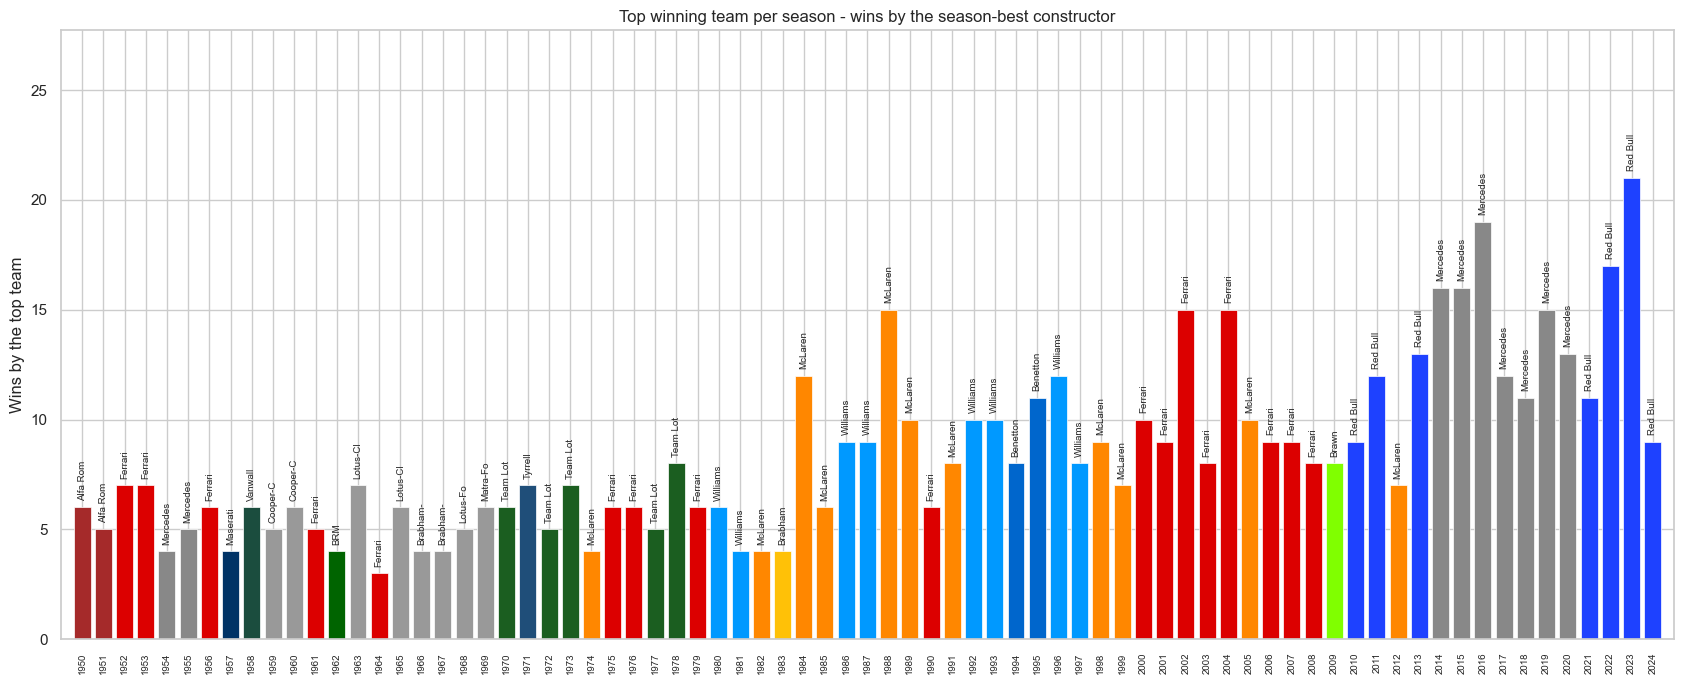

In [115]:
# Step 1 - wins per (year, team)
wins_per_year_team = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId')
    .merge(constructors[['constructorId', 'team']], on='constructorId')
    .groupby(['year', 'team']).size()
    .reset_index(name='wins')
)

# Step 2 - for each year, the team with the most wins (tie-break: alphabetic)
top_team_per_year = (
    wins_per_year_team
    .sort_values(['year', 'wins', 'team'], ascending=[True, False, True])
    .groupby('year').head(1)
    .reset_index(drop=True)
)

print(f'{len(top_team_per_year)} seasons covered.')
print()
print(top_team_per_year.to_string(index=False))

# Step 3 - chart
fig, ax = plt.subplots(figsize=(17, 7))
bar_colors = [team_color(t) for t in top_team_per_year['team']]
ax.bar(top_team_per_year['year'], top_team_per_year['wins'],
       color=bar_colors, edgecolor='white', linewidth=0.5)

# Team marker ABOVE each bar (every year, short prefix so they don't collide)
for _, row in top_team_per_year.iterrows():
    ax.text(row['year'], row['wins'] + 0.3, row['team'][:8],
            ha='center', va='bottom', fontsize=7, rotation=90)

# Year label BELOW each bar - rotated so they all fit even when seasons are dense
ax.set_xticks(top_team_per_year['year'])
ax.set_xticklabels(top_team_per_year['year'].astype(str),
                   rotation=90, fontsize=7)

ax.set_title('Top winning team per season - wins by the season-best constructor')
ax.set_xlabel('')   # year labels under each bar already make this redundant
ax.set_ylabel('Wins by the top team')
ax.set_xlim(1949, 2025)
ax.set_ylim(0, top_team_per_year['wins'].max() * 1.32)
plt.tight_layout()
show_and_save('4.1_top_team_per_season.png')


### Chart 4.2 — Top 10 teams by all-time race wins

Total race wins across the entire history of F1, per constructor.

Top 10 teams by all-time race wins (with activity span):
      team  wins            active
   Ferrari   249 1950-2024, 75 yrs
   McLaren   185 1968-2024, 55 yrs
  Mercedes   129 1954-2024, 17 yrs
  Red Bull   122 2005-2024, 20 yrs
  Williams   114 1975-2024, 49 yrs
Team Lotus    45 1958-1994, 29 yrs
   Renault    35 1977-2020, 24 yrs
  Benetton    27 1986-2001, 16 yrs
   Tyrrell    23 1970-1998, 29 yrs
   Brabham    23 1962-1992, 22 yrs


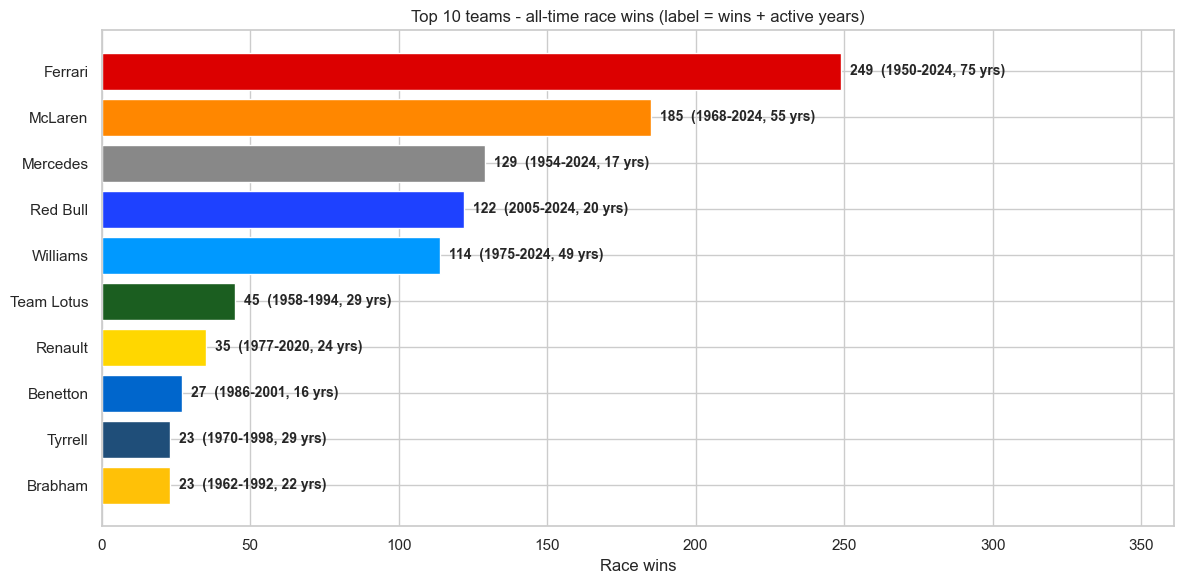

In [116]:
team_wins = (
    results[results['positionOrder'] == 1]
    .merge(constructors[['constructorId', 'team']], on='constructorId')
    .groupby('team').size()
    .reset_index(name='wins')
    .sort_values('wins', ascending=False)
    .head(10)
    .sort_values('wins')   # ascending -> biggest at top after barh
)
print('Top 10 teams by all-time race wins (with activity span):')
print(team_wins[['team', 'wins']]
      .sort_values('wins', ascending=False)
      .assign(active=lambda d: d['team'].apply(team_span_label))
      .to_string(index=False))

plt.figure(figsize=(12, 6))
bar_colors = [team_color(t) for t in team_wins['team']]
plt.barh(range(len(team_wins)), team_wins['wins'], color=bar_colors, edgecolor='white')
plt.yticks(range(len(team_wins)), team_wins['team'])

# Label: <wins>  (YYYY-YYYY, N yrs)
for i, row in enumerate(team_wins.itertuples()):
    plt.text(row.wins + 3, i, f'{row.wins}  ({team_span_label(row.team)})',
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 teams - all-time race wins (label = wins + active years)')
plt.xlabel('Race wins')
plt.ylabel('')
plt.xlim(0, team_wins['wins'].max() * 1.45)
plt.tight_layout()
show_and_save('4.2_team_wins.png')


### Chart 4.3 — Top 10 teams by pole positions (1950–2024)

Pole = `grid == 1` in `results`. Aggregated to team level. We use `results.grid` rather than `qualifying.csv` so the chart covers the **whole F1 history**, not just 1994+ when qualifying was recorded separately.

Top 10 teams by pole positions (with activity span):
        team  poles            active
     Ferrari    258 1950-2024, 75 yrs
     McLaren    164 1968-2024, 55 yrs
    Mercedes    142 1954-2024, 17 yrs
    Williams    128 1975-2024, 49 yrs
    Red Bull    103 2005-2024, 20 yrs
  Team Lotus     61 1958-1994, 29 yrs
     Renault     51 1977-2020, 24 yrs
Lotus-Climax     29  1961-1967, 7 yrs
     Brabham     26 1962-1992, 22 yrs
  Lotus-Ford     19  1963-1971, 6 yrs


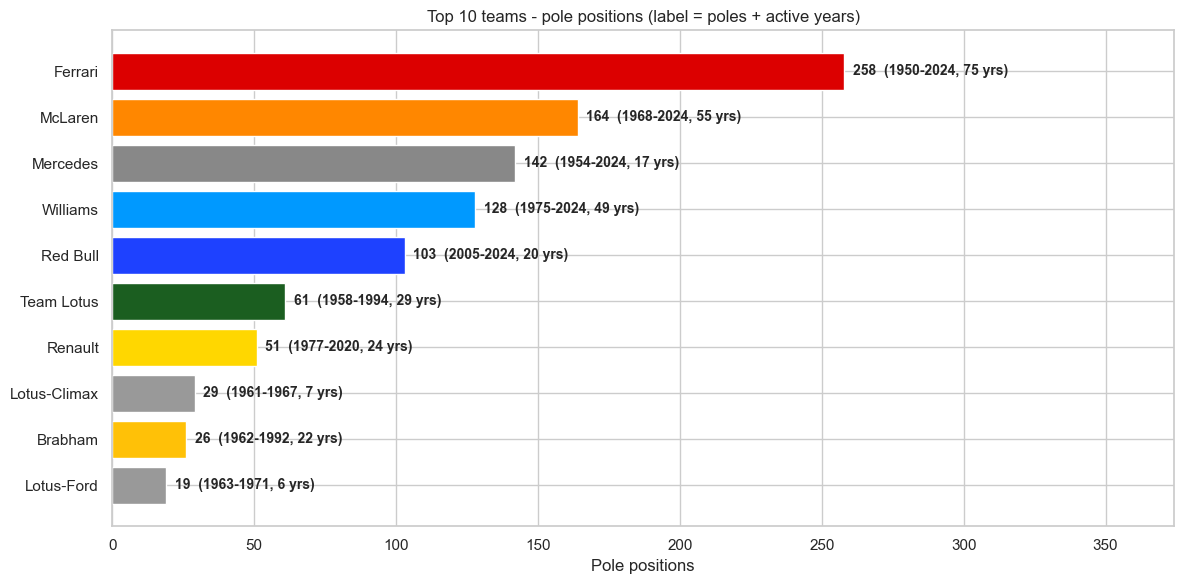

In [117]:
team_poles = (
    results[results['grid'] == 1]
    .merge(constructors[['constructorId', 'team']], on='constructorId')
    .groupby('team').size()
    .reset_index(name='poles')
    .sort_values('poles', ascending=False)
    .head(10)
    .sort_values('poles')
)
print('Top 10 teams by pole positions (with activity span):')
print(team_poles[['team', 'poles']]
      .sort_values('poles', ascending=False)
      .assign(active=lambda d: d['team'].apply(team_span_label))
      .to_string(index=False))

plt.figure(figsize=(12, 6))
bar_colors = [team_color(t) for t in team_poles['team']]
plt.barh(range(len(team_poles)), team_poles['poles'], color=bar_colors, edgecolor='white')
plt.yticks(range(len(team_poles)), team_poles['team'])

for i, row in enumerate(team_poles.itertuples()):
    plt.text(row.poles + 3, i, f'{row.poles}  ({team_span_label(row.team)})',
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 teams - pole positions (label = poles + active years)')
plt.xlabel('Pole positions')
plt.ylabel('')
plt.xlim(0, team_poles['poles'].max() * 1.45)
plt.tight_layout()
show_and_save('4.3_team_poles.png')


### Chart 4.4 — Top 5 winners inside each of the top 10 teams

Two-level breakdown: first identify the 10 teams with the most all-time wins, then for each of those teams show the 5 drivers who delivered the most wins for it. Rendered as a 2×5 grid of small multiples — each subplot is one team.

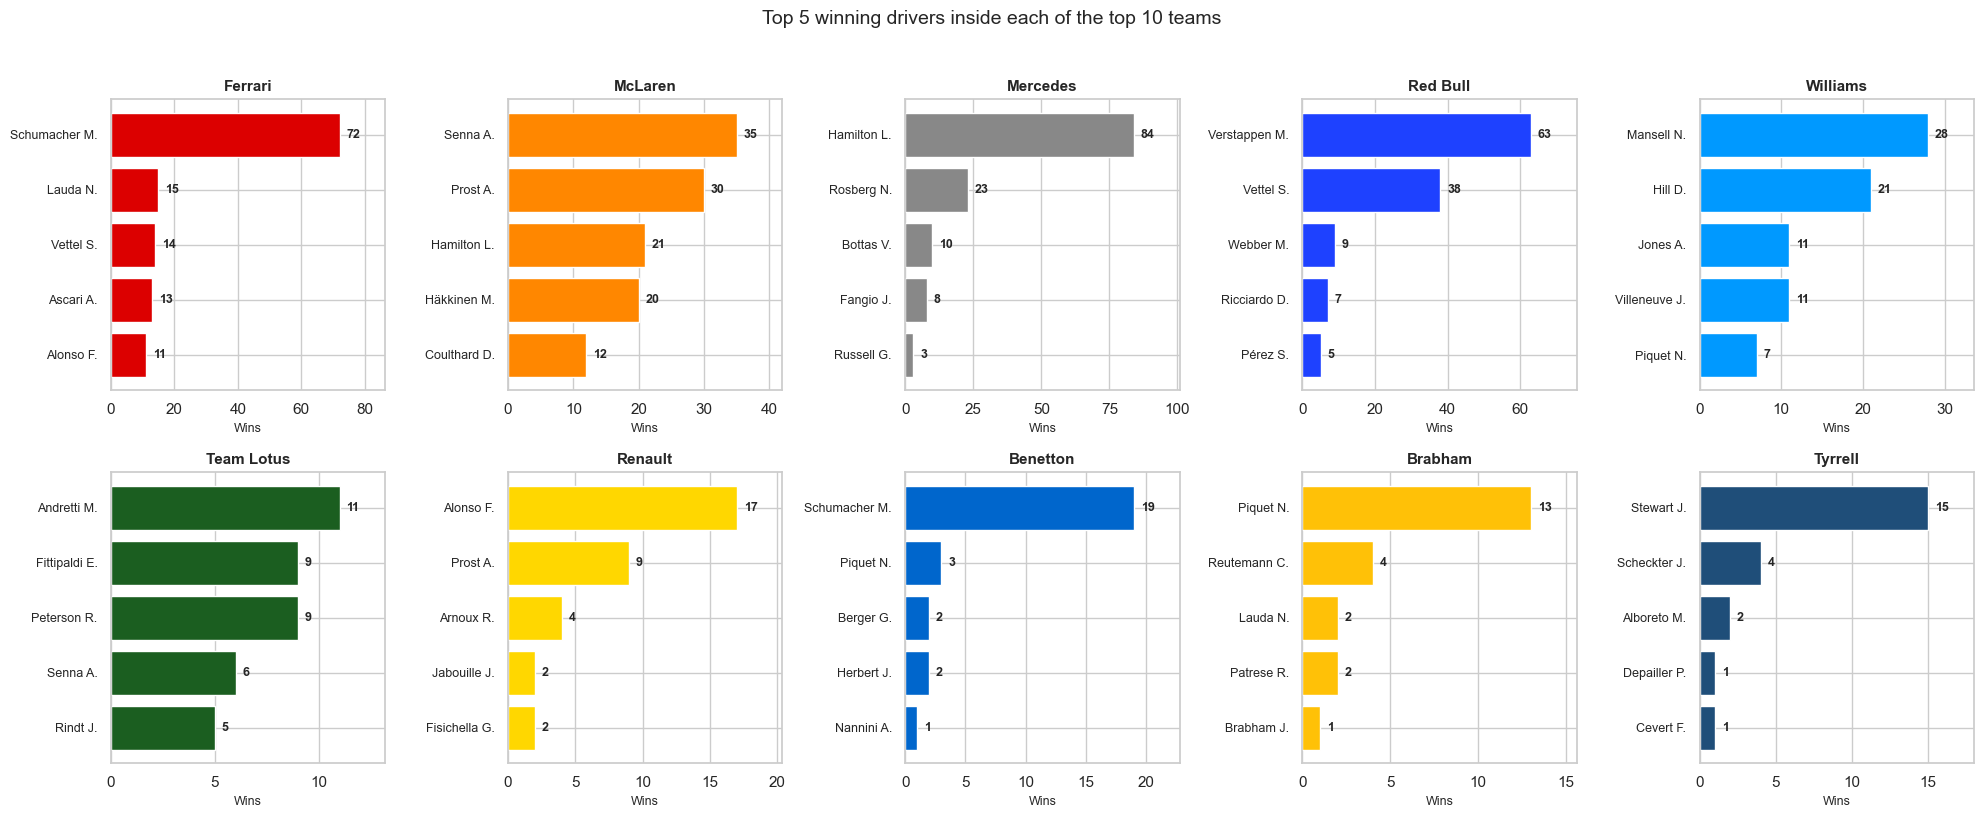

In [118]:
# Top 10 teams (by all-time wins) — same set as 4.2
top10_team_ids = (
    results[results['positionOrder'] == 1]
    .merge(constructors[['constructorId', 'team']], on='constructorId')
    .groupby(['constructorId', 'team']).size()
    .reset_index(name='wins')
    .sort_values('wins', ascending=False)
    .head(10)
)

# For each of those teams, top 5 drivers by wins for that team
winners_per_team = (
    results[results['positionOrder'] == 1]
    .merge(top10_team_ids[['constructorId', 'team']], on='constructorId')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .groupby(['team', 'driver']).size()
    .reset_index(name='wins')
    .sort_values(['team', 'wins'], ascending=[True, False])
)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=False)
axes = axes.flatten()

# Iterate in the same order as the top10 ranking
ordered_teams = top10_team_ids.sort_values('wins', ascending=False)['team'].tolist()
for ax, team in zip(axes, ordered_teams):
    sub = winners_per_team[winners_per_team['team'] == team].head(5).sort_values('wins')
    color = team_color(team)
    ax.barh(range(len(sub)), sub['wins'], color=color, edgecolor='white')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['driver'], fontsize=9)
    for i, row in enumerate(sub.itertuples()):
        ax.text(row.wins + max(sub['wins']) * 0.03, i, str(row.wins),
                va='center', fontsize=9, fontweight='bold')
    ax.set_title(team, fontsize=11, fontweight='bold')
    ax.set_xlim(0, sub['wins'].max() * 1.20)
    ax.set_xlabel('Wins', fontsize=9)

fig.suptitle('Top 5 winning drivers inside each of the top 10 teams',
             fontsize=14, y=1.02)
fig.tight_layout()
show_and_save('4.4_top_winners_per_team.png')

### Chart 4.5 — Top 10 teams by number of unique drivers

`COUNT(DISTINCT driverId)` per team. Long-running teams (Ferrari, Williams, McLaren) accumulate large rosters; short-lived teams stay small. Race-entries doesn't matter here — Trulli racing 240 times for Toyota counts as 1 driver.

Top 10 teams by number of unique drivers (with activity span):
         team  unique_drivers            active
      Ferrari              98 1950-2024, 75 yrs
     Maserati              89 1950-1960, 11 yrs
          BRM              70 1951-1977, 23 yrs
     Williams              62 1975-2024, 49 yrs
   Team Lotus              61 1958-1994, 29 yrs
Cooper-Climax              58  1959-1968, 9 yrs
 Lotus-Climax              55  1961-1967, 7 yrs
      McLaren              55 1968-2024, 55 yrs
      Brabham              49 1962-1992, 22 yrs
        March              48 1970-1992, 13 yrs


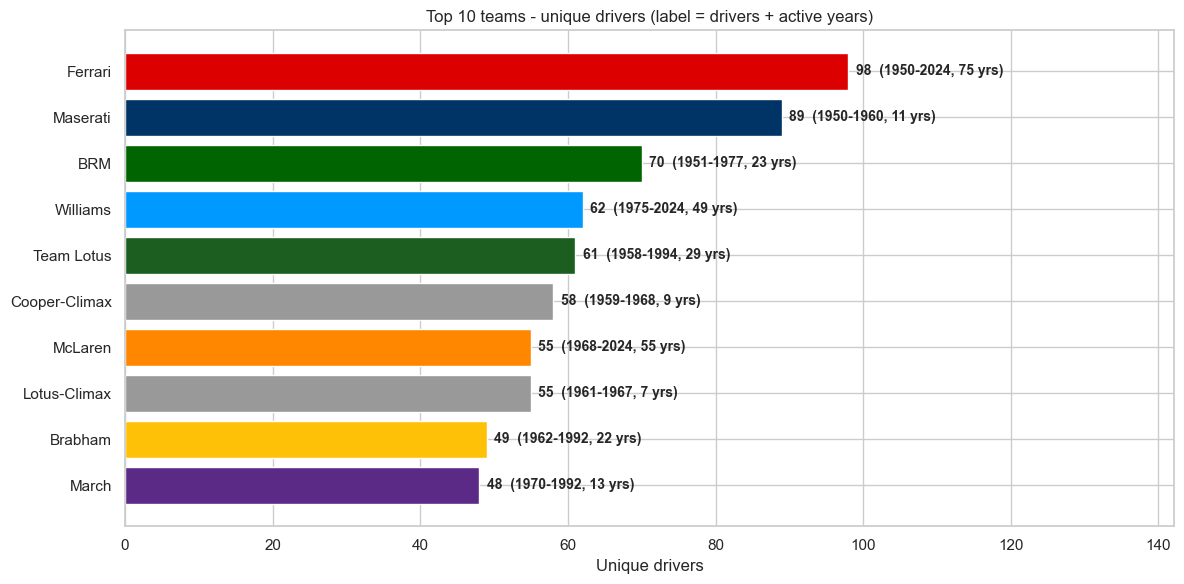

In [119]:
team_drivers = (
    results.merge(constructors[['constructorId', 'team']], on='constructorId')
    .groupby('team')['driverId'].nunique()
    .reset_index(name='unique_drivers')
    .sort_values('unique_drivers', ascending=False)
    .head(10)
    .sort_values('unique_drivers')
)
print('Top 10 teams by number of unique drivers (with activity span):')
print(team_drivers[['team', 'unique_drivers']]
      .sort_values('unique_drivers', ascending=False)
      .assign(active=lambda d: d['team'].apply(team_span_label))
      .to_string(index=False))

plt.figure(figsize=(12, 6))
bar_colors = [team_color(t) for t in team_drivers['team']]
plt.barh(range(len(team_drivers)), team_drivers['unique_drivers'],
         color=bar_colors, edgecolor='white')
plt.yticks(range(len(team_drivers)), team_drivers['team'])

for i, row in enumerate(team_drivers.itertuples()):
    plt.text(row.unique_drivers + 1, i,
             f'{row.unique_drivers}  ({team_span_label(row.team)})',
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 teams - unique drivers (label = drivers + active years)')
plt.xlabel('Unique drivers')
plt.ylabel('')
plt.xlim(0, team_drivers['unique_drivers'].max() * 1.45)
plt.tight_layout()
show_and_save('4.5_team_unique_drivers.png')


### Chart 4.6 — Wire-to-wire constructor seasons (1958+)

For each season, check whether the **same team led the constructor standings after every single race**. If yes, that's a wire-to-wire season — they were never overtaken at any point.

The Constructors' Championship started in **1958**, so earlier seasons can't be measured this way. We list every wire-to-wire season as a table (row-by-row context), then aggregate into a **top-5 team bar** so you can see which constructors have had the most wire-to-wire seasons.

Wire-to-wire constructor seasons (1958+): 23

 year          team  rounds
 1959 Cooper-Climax       8
 1960 Cooper-Climax       9
 1968    Lotus-Ford      12
 1969    Matra-Ford      11
 1976       Ferrari      16
 1978    Team Lotus      16
 1981      Williams      15
 1984       McLaren      16
 1988       McLaren      16
 1990       McLaren      16
 1992      Williams      16
 1996      Williams      16
 1998       McLaren      16
 2001       Ferrari      17
 2004       Ferrari      18
 2007       Ferrari      17
 2009         Brawn      17
 2011      Red Bull      19
 2015      Mercedes      19
 2016      Mercedes      21
 2019      Mercedes      21
 2020      Mercedes      17
 2023      Red Bull      22


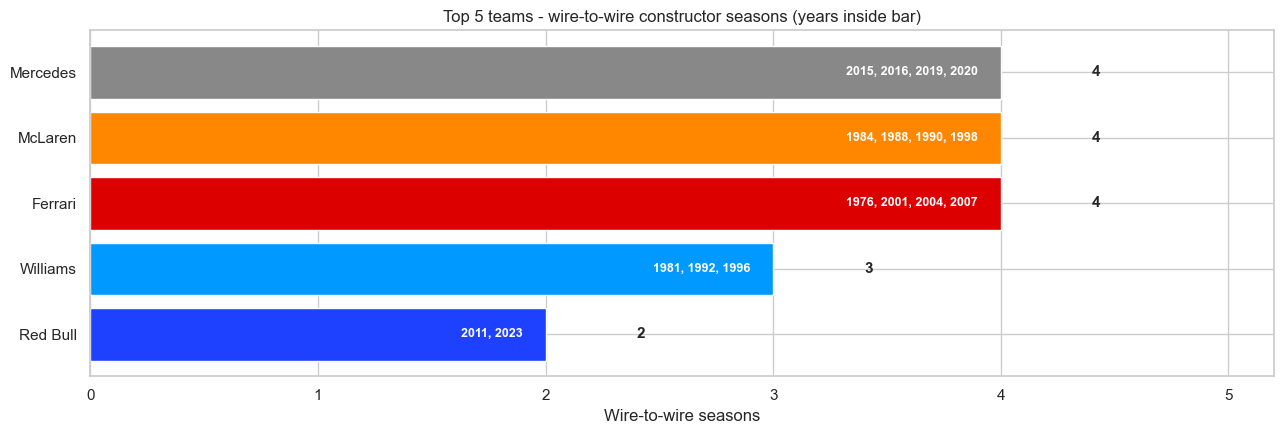

In [120]:
# Step 1 - for each (year, round), find the leader (position == 1)
cs = (constructor_standings
      .merge(races[['raceId', 'year', 'round']], on='raceId')
      .merge(constructors[['constructorId', 'team']], on='constructorId'))

leaders_per_round = cs.loc[cs['position'] == 1, ['year', 'round', 'team']].drop_duplicates()

# Step 2 - for each year, was the leader the same team in every round?
wire_to_wire_years = (leaders_per_round.groupby('year')
                      .filter(lambda g: g['team'].nunique() == 1)
                      .groupby('year')['team'].first()
                      .reset_index(name='team'))

rounds_per_year = leaders_per_round.groupby('year').size().reset_index(name='rounds')
wire_to_wire_years = wire_to_wire_years.merge(rounds_per_year, on='year')

print(f'Wire-to-wire constructor seasons (1958+): {len(wire_to_wire_years)}')
print()
print(wire_to_wire_years.to_string(index=False))

# Aggregate per team: count + list of years
wtw_per_team = (wire_to_wire_years.groupby('team')
                .agg(wire_to_wire_seasons=('year', 'count'),
                     years=('year', lambda s: ', '.join(str(y) for y in sorted(s))))
                .reset_index()
                .sort_values('wire_to_wire_seasons', ascending=False)
                .head(5)
                .sort_values('wire_to_wire_seasons'))

plt.figure(figsize=(13, 4.5))
bar_colors = [team_color(t) for t in wtw_per_team['team']]
plt.barh(range(len(wtw_per_team)), wtw_per_team['wire_to_wire_seasons'],
         color=bar_colors, edgecolor='white')
plt.yticks(range(len(wtw_per_team)), wtw_per_team['team'])

# Two labels per bar:
#   (a) the years INSIDE the bar (white text), right-aligned at the bar's end
#   (b) the count just to the right of the bar
for i, row in enumerate(wtw_per_team.itertuples()):
    # Years inside the bar (only if bar is long enough)
    if row.wire_to_wire_seasons >= 2:
        plt.text(row.wire_to_wire_seasons - 0.1, i, row.years,
                 va='center', ha='right', fontsize=9, color='white',
                 fontweight='bold')
    else:
        # If the bar is only 1 unit wide, the year wouldn't fit inside -
        # put it just after the bar instead, in the team's color
        plt.text(row.wire_to_wire_seasons + 0.05, i, f'  {row.years}',
                 va='center', fontsize=9, color='#444444')
    # Count after the bar
    plt.text(row.wire_to_wire_seasons + 0.4, i, str(row.wire_to_wire_seasons),
             va='center', fontsize=11, fontweight='bold')

plt.title('Top 5 teams - wire-to-wire constructor seasons (years inside bar)')
plt.xlabel('Wire-to-wire seasons')
plt.ylabel('')
plt.xlim(0, wtw_per_team['wire_to_wire_seasons'].max() * 1.30)
plt.tight_layout()
show_and_save('4.6_wire_to_wire_constructors.png')


### Chart 4.7 — Longest consecutive race-win streak by constructor

Sort all races chronologically. For each consecutive run of races won by the same constructor, record the run length. Take the **maximum** per constructor; rank top 10.

Top 10 constructors by longest consecutive race-win streak:
         team  streak_len     years
     Red Bull          15 2022-2023
      Ferrari          14 1952-1953
      McLaren          11      1988
     Mercedes          10 2015-2016
   Alfa Romeo          10 1950-1951
     Williams           7      1993
Cooper-Climax           5      1960
   Lotus-Ford           5 1967-1968
 Lotus-Climax           5      1965
      Renault           4 2005-2006


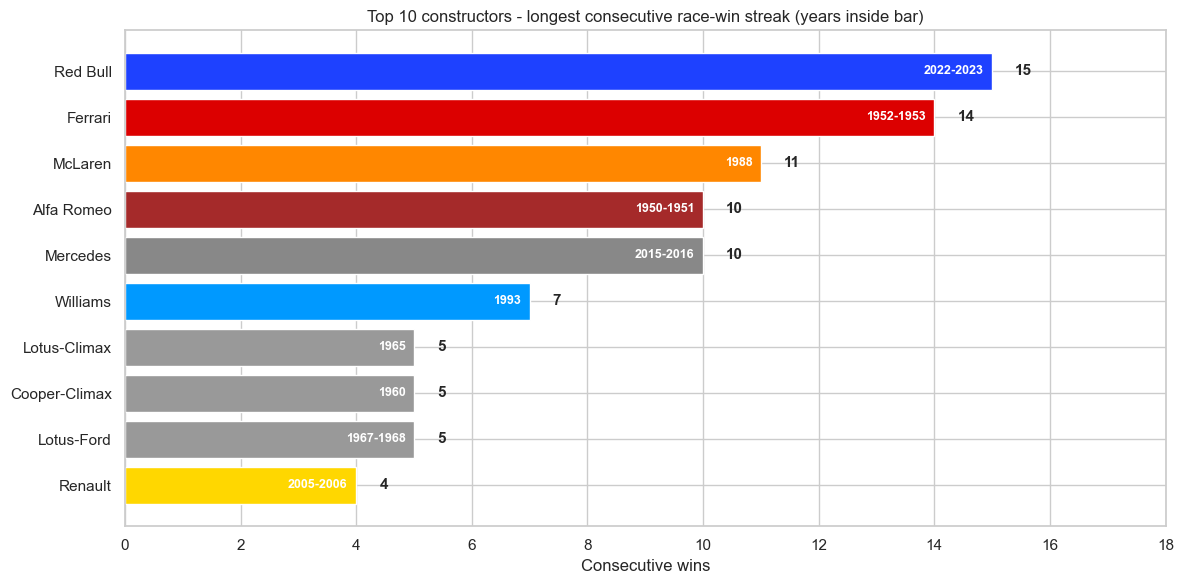

In [121]:
# Step 1 - winner of each race, in chronological order
race_winners = (
    results[results['positionOrder'] == 1][['raceId', 'constructorId']]
    .merge(races[['raceId', 'date', 'year']], on='raceId')
    .merge(constructors[['constructorId', 'team']], on='constructorId')
    .sort_values('date')
    .reset_index(drop=True)
)

# Step 2 - run-length encoding: each time the winning constructor flips, start a new group
race_winners['streak_grp'] = (race_winners['constructorId']
                              != race_winners['constructorId'].shift()).cumsum()

# Step 3 - for each team, find the longest run + the years it spanned
streak_info = (race_winners.groupby(['streak_grp', 'team'])
               .agg(streak_len=('raceId', 'count'),
                    year_first=('year', 'min'),
                    year_last=('year', 'max'))
               .reset_index())

# Pick each team's BEST run (largest streak)
best_streak_per_team = (streak_info.sort_values('streak_len', ascending=False)
                        .groupby('team').head(1)
                        .reset_index(drop=True))

max_streak_per_team = (best_streak_per_team
                       .sort_values('streak_len', ascending=False)
                       .head(10)
                       .sort_values('streak_len'))

# Pretty year label: '2002' or '2022-2023'
def _yrlabel(a, b):
    a, b = int(a), int(b)
    return f'{a}' if a == b else f'{a}-{b}'

print('Top 10 constructors by longest consecutive race-win streak:')
print(max_streak_per_team
      .assign(years=lambda d: d.apply(lambda r: _yrlabel(r['year_first'], r['year_last']),
                                       axis=1))
      [['team', 'streak_len', 'years']]
      .sort_values('streak_len', ascending=False)
      .to_string(index=False))

plt.figure(figsize=(12, 6))
bar_colors = [team_color(t) for t in max_streak_per_team['team']]
plt.barh(range(len(max_streak_per_team)), max_streak_per_team['streak_len'],
         color=bar_colors, edgecolor='white')
plt.yticks(range(len(max_streak_per_team)), max_streak_per_team['team'])

for i, row in enumerate(max_streak_per_team.itertuples()):
    yr = _yrlabel(row.year_first, row.year_last)
    # Years inside the bar (white, right-aligned)
    if row.streak_len >= 3:
        plt.text(row.streak_len - 0.15, i, yr,
                 va='center', ha='right', fontsize=9, color='white',
                 fontweight='bold')
    else:
        plt.text(row.streak_len + 0.05, i, yr,
                 va='center', fontsize=9, color='#444444')
    # Streak length after the bar
    plt.text(row.streak_len + 0.4, i, str(row.streak_len),
             va='center', fontsize=11, fontweight='bold')

plt.title('Top 10 constructors - longest consecutive race-win streak (years inside bar)')
plt.xlabel('Consecutive wins')
plt.ylabel('')
plt.xlim(0, max_streak_per_team['streak_len'].max() * 1.20)
plt.tight_layout()
show_and_save('4.7_longest_constructor_streak.png')


### Chart 4.8 — Biggest year-over-year jump in constructor standings (1958+)

For each constructor, compare its **final** standings position in year N to year N–1. A jump from P9 → P3 = improvement of 6 positions. Top 10 biggest jumps.

Constraint: both years need a recorded final standing for the same constructor — so first-year teams are excluded automatically.

Top 10 biggest year-over-year constructor standings jumps:
           team  from_year  to_year change  improvement
Cooper-Maserati     1965.0     1966 16 → 3         13.0
           Wolf     1976.0     1977 15 → 4         11.0
       Footwork     1991.0     1992 18 → 7         11.0
   McLaren-Ford     1967.0     1968 12 → 2         10.0
      Larrousse     1989.0     1990 16 → 6         10.0
        Tyrrell     1970.0     1971 11 → 1         10.0
          Matra     1967.0     1968 18 → 9          9.0
        McLaren     2007.0     2008 11 → 2          9.0
           Lola     1985.0     1986 17 → 8          9.0
         Penske     1975.0     1976 12 → 5          7.0


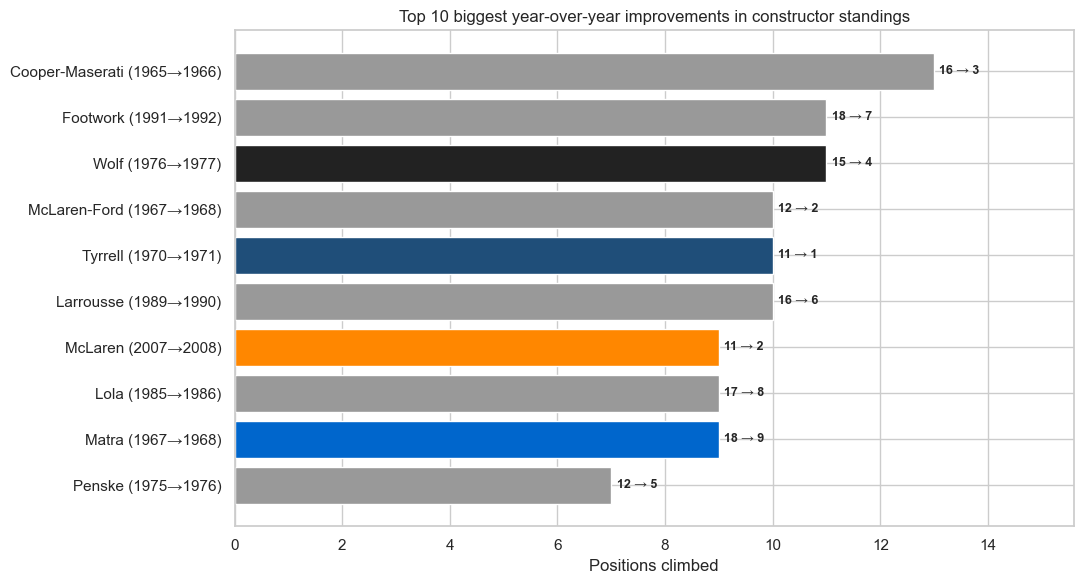

In [122]:
# Last race of each season (the round where final standings are set)
last_race_per_year = (
    races.assign(date=lambda d: pd.to_datetime(d['date']))
    .sort_values('date')
    .groupby('year').last()
    .reset_index()[['year', 'raceId']]
)

final = (constructor_standings
         .merge(last_race_per_year, on='raceId')
         .merge(constructors[['constructorId', 'team']], on='constructorId')
         [['constructorId', 'team', 'year', 'position']]
         .sort_values(['constructorId', 'year']))

final['prev_position'] = final.groupby('constructorId')['position'].shift(1)
final['prev_year']     = final.groupby('constructorId')['year'].shift(1)
final['improvement']   = final['prev_position'] - final['position']  # positive = climbed

# Only count consecutive-year jumps (gap year is too noisy to compare)
yoy = final[final['year'] - final['prev_year'] == 1].copy()
yoy['change'] = (yoy['prev_position'].astype('Int64').astype(str)
                 + ' → ' + yoy['position'].astype('Int64').astype(str))

top10_jumps = (yoy.sort_values('improvement', ascending=False)
               .head(10)
               .copy())

print('Top 10 biggest year-over-year constructor standings jumps:')
print(top10_jumps[['team', 'prev_year', 'year', 'change', 'improvement']]
      .rename(columns={'prev_year': 'from_year', 'year': 'to_year'})
      .to_string(index=False))

# Chart — horizontal bar, label = team + year transition
top10_jumps_sorted = top10_jumps.sort_values('improvement')
labels = (top10_jumps_sorted['team'] + ' ('
          + top10_jumps_sorted['prev_year'].astype('Int64').astype(str)
          + '→' + top10_jumps_sorted['year'].astype('Int64').astype(str) + ')')

plt.figure(figsize=(11, 6))
bar_colors = [team_color(t) for t in top10_jumps_sorted['team']]
plt.barh(range(len(top10_jumps_sorted)),
         top10_jumps_sorted['improvement'],
         color=bar_colors, edgecolor='white')
plt.yticks(range(len(top10_jumps_sorted)), labels)

for i, row in enumerate(top10_jumps_sorted.itertuples()):
    plt.text(row.improvement + 0.1, i,
             f'{int(row.prev_position)} → {int(row.position)}',
             va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 biggest year-over-year improvements in constructor standings')
plt.xlabel('Positions climbed')
plt.ylabel('')
plt.xlim(0, top10_jumps_sorted['improvement'].max() * 1.20)
plt.tight_layout()
show_and_save('4.8_biggest_yoy_improvement.png')

### Chart 4.9 — Constructors that never scored a podium

Anti-join: every constructor that has at least one race entry but **zero** P1–P3 finishes. Output as a table sorted by total race entries (largest first), so the most-prolific never-podium teams appear at the top.

In [123]:
podium_constructor_ids = set(
    results.loc[results['positionOrder'] <= 3, 'constructorId']
)

never_podium_ids = set(constructors['constructorId']) - podium_constructor_ids

never_podium = (
    constructors[constructors['constructorId'].isin(never_podium_ids)]
    .merge(results.groupby('constructorId').size().reset_index(name='entries'),
           on='constructorId', how='left')
    .merge(results.merge(races[['raceId', 'year']], on='raceId')
           .groupby('constructorId')['year']
           .agg(['min', 'max']).reset_index(),
           on='constructorId', how='left')
    .rename(columns={'min': 'first_year', 'max': 'last_year'})
    .sort_values('entries', ascending=False, na_position='last')
    .reset_index(drop=True)
    [['team', 'nationality', 'entries', 'first_year', 'last_year']]
)

print(f'Constructors that never scored a podium: {len(never_podium)}')
print()
# Top 30 by entries — the rest are mostly one-off teams
print(never_podium.head(30).to_string(index=False))

Constructors that never scored a podium: 143

              team nationality  entries  first_year  last_year
           Minardi     Italian    672.0      1985.0     2005.0
      Haas F1 Team    American    380.0      2016.0     2024.0
            Osella     Italian    252.0      1980.0     1990.0
               ATS     Italian    162.0      1963.0     1984.0
            Ensign     British    154.0      1973.0     1982.0
          Zakspeed      German    133.0      1985.0     1989.0
               AGS      French    123.0      1986.0     1991.0
               HRT     Spanish    116.0      2010.0     2012.0
          Caterham   Malaysian    112.0      2012.0     2014.0
          Marussia     Russian    109.0      2012.0     2014.0
            Coloni     Italian     81.0      1987.0     1991.0
       Super Aguri    Japanese     78.0      2006.0     2008.0
    Manor Marussia     British     78.0      2015.0     2016.0
            Virgin     British     76.0      2010.0     2011.0
         

### Chart 4.10 — Top 10 teams by total race entries

A "race entry" = one driver-race row in `results` belonging to that team. Long-lived teams with multi-car entries dominate.

Top 10 teams by total race entries (with activity span):
      team  entries            active
   Ferrari     2438 1950-2024, 75 yrs
   McLaren     1923 1968-2024, 55 yrs
  Williams     1676 1975-2024, 49 yrs
   Tyrrell      881 1970-1998, 29 yrs
Team Lotus      871 1958-1994, 29 yrs
    Sauber      837 1993-2024, 23 yrs
  Red Bull      788 2005-2024, 20 yrs
   Renault      787 1977-2020, 24 yrs
   Minardi      672 1985-2005, 21 yrs
   Brabham      662 1962-1992, 22 yrs


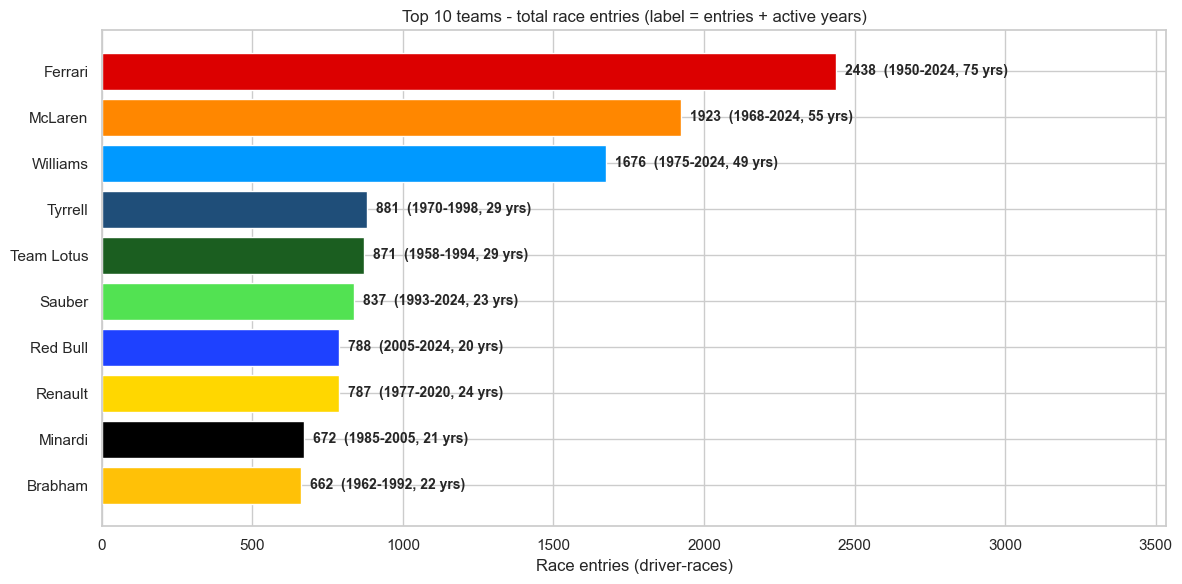

In [124]:
team_entries = (
    results.merge(constructors[['constructorId', 'team']], on='constructorId')
    .groupby('team').size()
    .reset_index(name='entries')
    .sort_values('entries', ascending=False)
    .head(10)
    .sort_values('entries')
)
print('Top 10 teams by total race entries (with activity span):')
print(team_entries[['team', 'entries']]
      .sort_values('entries', ascending=False)
      .assign(active=lambda d: d['team'].apply(team_span_label))
      .to_string(index=False))

plt.figure(figsize=(12, 6))
bar_colors = [team_color(t) for t in team_entries['team']]
plt.barh(range(len(team_entries)), team_entries['entries'],
         color=bar_colors, edgecolor='white')
plt.yticks(range(len(team_entries)), team_entries['team'])

for i, row in enumerate(team_entries.itertuples()):
    plt.text(row.entries + 30, i,
             f'{row.entries}  ({team_span_label(row.team)})',
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 teams - total race entries (label = entries + active years)')
plt.xlabel('Race entries (driver-races)')
plt.ylabel('')
plt.xlim(0, team_entries['entries'].max() * 1.45)
plt.tight_layout()
show_and_save('4.10_team_entries.png')


### Chart 4.11 — Top 10 teams with the fewest race entries

The other end of the distribution. Filtered to constructors with **at least 1 entry** (some constructor IDs in the data exist but never raced; we drop those). Includes plenty of single-shot teams from the chaotic early years and 1990s back-of-grid attempts.

Cap: bottom 10 within constructors that *did* enter at least one race. If multiple teams are tied (many 1-entry teams exist), the table just shows the first 10 in alphabetic order.

Top 10 teams by FEWEST race entries (with activity span):
             team nationality  entries      active
   Arzani-Volpini     Italian        1 1955, 1 yrs
          Apollon       Swiss        1 1977, 1 yrs
          Bugatti      French        1 1956, 1 yrs
         BRM-Ford     British        1 1969, 1 yrs
           Connew     British        1 1972, 1 yrs
       Cooper-ATS     British        1 1967, 1 yrs
Cooper-Alfa Romeo     British        1 1962, 1 yrs
       Derrington     British        1 1964, 1 yrs
De Tomaso-Ferrari     Italian        1 1963, 1 yrs
              ENB     Belgian        1 1962, 1 yrs


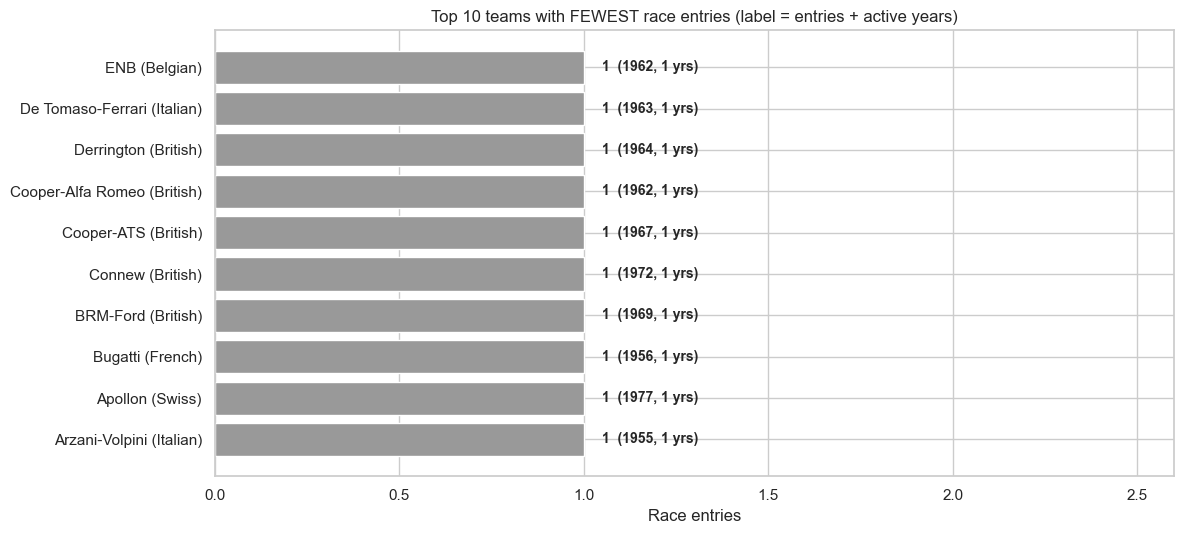

In [125]:
all_team_entries = (
    results.merge(constructors[['constructorId', 'team', 'nationality']], on='constructorId')
    .groupby(['team', 'nationality']).size()
    .reset_index(name='entries')
    .query('entries >= 1')
    .sort_values('entries')
    .head(10)
    .sort_values('entries', ascending=False)   # smallest at top after barh inversion
)
print('Top 10 teams by FEWEST race entries (with activity span):')
print(all_team_entries[['team', 'nationality', 'entries']]
      .sort_values('entries')
      .assign(active=lambda d: d['team'].apply(team_span_label))
      .to_string(index=False))

plt.figure(figsize=(12, 5.5))
bar_colors = [team_color(t) for t in all_team_entries['team']]
plt.barh(range(len(all_team_entries)), all_team_entries['entries'],
         color=bar_colors, edgecolor='white')
plt.yticks(range(len(all_team_entries)),
           all_team_entries['team'] + ' (' + all_team_entries['nationality'] + ')')

for i, row in enumerate(all_team_entries.itertuples()):
    plt.text(row.entries + 0.05, i,
             f'{row.entries}  ({team_span_label(row.team)})',
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 teams with FEWEST race entries (label = entries + active years)')
plt.xlabel('Race entries')
plt.ylabel('')
plt.xlim(0, all_team_entries['entries'].max() * 2.6)
plt.tight_layout()
show_and_save('4.11_team_fewest_entries.png')


### Charts 4.12 + 4.13 — Head-to-head teammate records

For every pair of drivers who shared a team in the same race, count:

- **Total races together** = the number of Sundays they both started in the same team's cars (any of their shared teams across years).
- **Driver A finished ahead of Driver B** = on-track head-to-head, ignoring DNFs and points scoring — just *who crossed the line first this Sunday*.

That gives a single percentage per pair: e.g. `Hamilton 58% vs Rosberg 42%` over 78 races together at Mercedes (2013–2016). The chart then ranks the pairs two ways:

- **4.12 — Most competitive**: pairs whose head-to-head split is closest to **50/50** (the analyst's `|pct − 50|` distance). These are the teammates you genuinely couldn't separate.
- **4.13 — Least competitive (most one-sided)**: pairs furthest from 50/50 — typically a senior driver vs a one-season rookie / fill-in driver.

#### How to read the bar
Each row is a stacked horizontal bar to 100 %:

- **Left, navy** = the percentage of races finished ahead by the driver listed **first** in the y-label
- **Right, burgundy** = percentage by the driver listed **second**
- The label after the names shows the **team(s)**, **year range**, and **races together** so you can judge sample size

We order the two drivers so the **winning** (higher %) driver always appears first — that way a clean 50/50 row reads "X 50% / Y 50%" and a one-sided one reads "X 92% / Y 8%". The colors are always navy on the left, burgundy on the right.

#### Filters
- **Min 15 races together** — pairs with fewer races are too noisy to interpret.
- A pair that raced at multiple teams (e.g. Hamilton at McLaren + Mercedes) has its records **summed** across teams; the label lists all teams shared.


Total teammate pairs analyzed (>=15 races together): 340

4.12 - Most competitive teammate pairs (closest to 50/50):
   winner_name    loser_name                  teams  races_together  winner_pct  first_year  last_year
 Kovalainen H.     Petrov V.               Caterham              20        50.0        2012       2012
     Schell H.      Behra J. BRM, Gordini, Maserati              32        50.0        1953       1958
      Sutil A.   di Resta P.            Force India              38        50.0        2011       2013
Trintignant M.   Hawthorn M.                Ferrari              16        50.0        1954       1957
       Hill G.    Stewart J.                    BRM              18        50.0        1965       1966
Barrichello R.    Brundle M.                 Jordan              16        50.0        1996       1996
 de Cesaris A. Giacomelli B.             Alfa Romeo              18        50.0        1980       1982
   Katayama U. de Cesaris A.                Tyrrell        

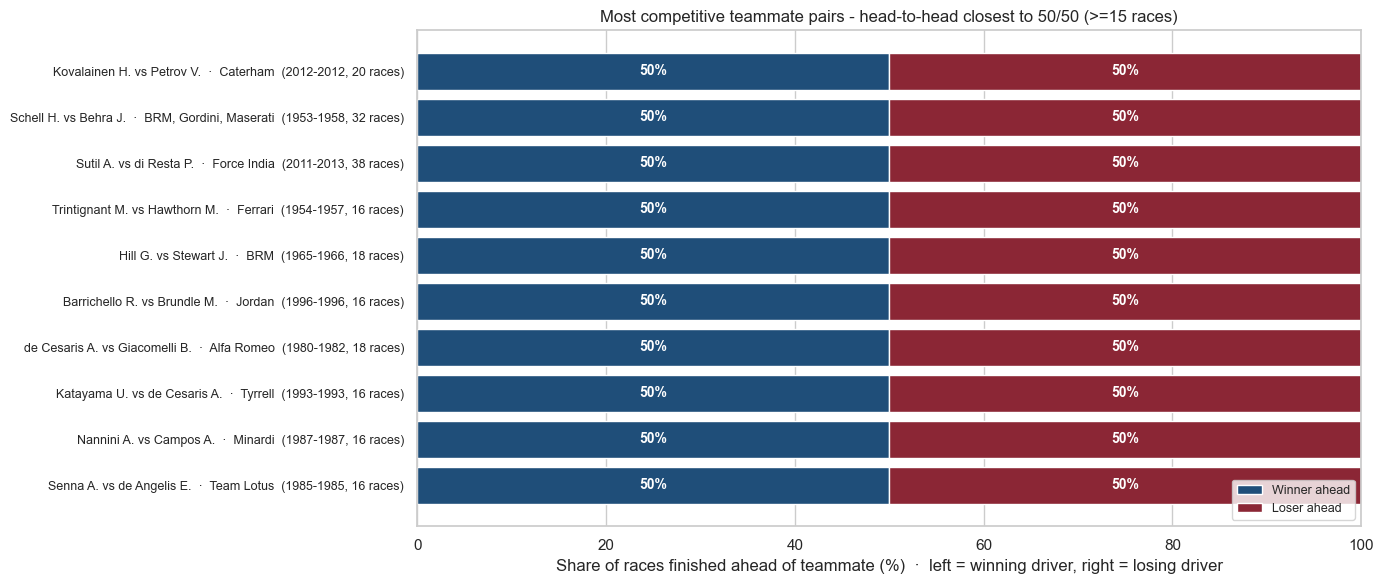


4.13 - Least competitive teammate pairs (most one-sided):
  winner_name      loser_name             teams  races_together  winner_pct  first_year  last_year
  Peterson R.     Beuttler M. March, March-Ford              15       100.0        1971       1972
    Modena S.     Nakajima S.           Tyrrell              16        93.8        1991       1991
    Button J.         Sato T.               BAR              35        91.4        2003       2005
    Kubica R.       Petrov V.           Renault              19        89.5        2010       2010
Verstappen M.        Pérez S.          Red Bull              90        87.8        2021       2024
  Frentzen H.         Hill D.            Jordan              16        87.5        1999       1999
     Senna A.     Nakajima S.        Team Lotus              16        87.5        1987       1987
    Larini N. van de Poele E.             Lambo              16        87.5        1991       1991
    Palmer J.       Bailey J.           Tyrrell   

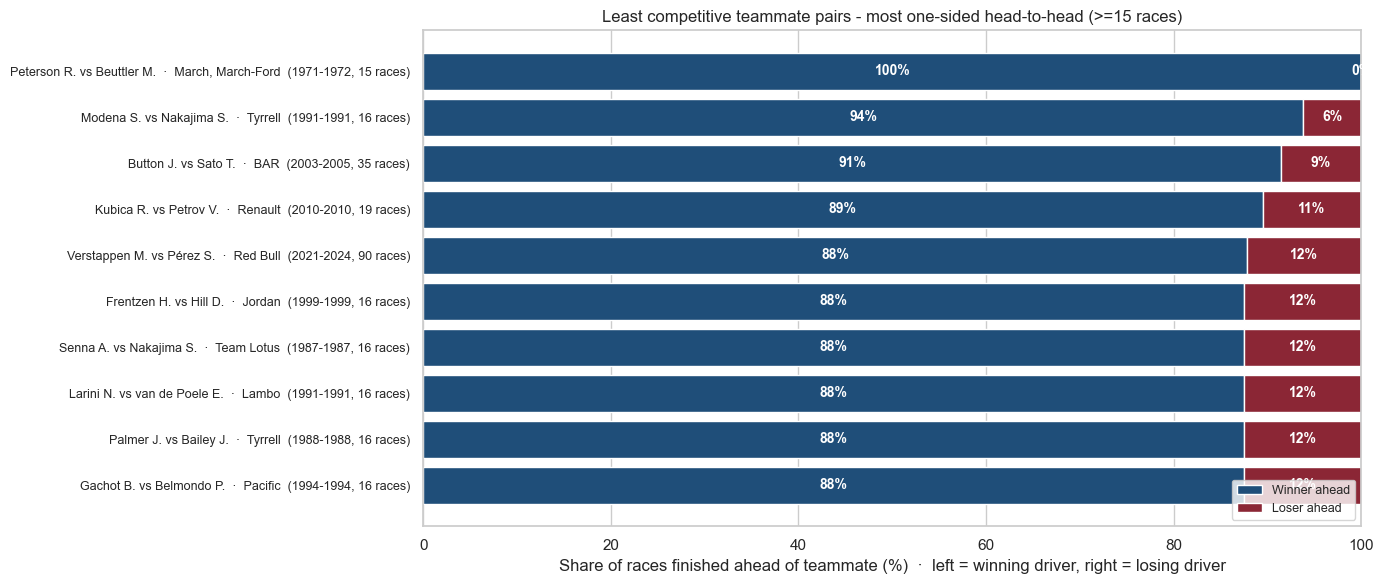

In [126]:
# Step 1 - annotate every result with the year
res_yr = (results[['raceId', 'driverId', 'constructorId', 'positionOrder']]
          .merge(races[['raceId', 'year']], on='raceId'))

# Step 2 - self-join on (raceId, constructorId): every (a, b) pairing of teammates per race
pairs = (
    res_yr.merge(res_yr, on=['raceId', 'constructorId', 'year'],
                 suffixes=('_a', '_b'))
    .query('driverId_a < driverId_b')   # dedupe + drop self-pairs
)

# Step 3 - aggregate per pair per team (so we can list teams in the label later)
def h2h_summary(grp):
    return pd.Series({
        'races_together': len(grp),
        'a_ahead':        int((grp['positionOrder_a'] < grp['positionOrder_b']).sum()),
        'first_year':     int(grp['year'].min()),
        'last_year':      int(grp['year'].max()),
    })

h2h_per_team = (pairs.groupby(['driverId_a', 'driverId_b', 'constructorId'])
                .apply(h2h_summary, include_groups=False)
                .reset_index()
                .merge(constructors[['constructorId', 'team']], on='constructorId'))

# Roll up per (pair) - sum the per-team records, and concat the team list
h2h_overall = (h2h_per_team.groupby(['driverId_a', 'driverId_b'])
               .agg(races_together=('races_together', 'sum'),
                    a_ahead=('a_ahead', 'sum'),
                    first_year=('first_year', 'min'),
                    last_year=('last_year', 'max'),
                    teams=('team', lambda s: ', '.join(sorted(set(s)))))
               .reset_index())

# Step 4 - filter to >=15 races together, compute percentages
h2h_sig = h2h_overall[h2h_overall['races_together'] >= 15].copy()
h2h_sig['a_ahead_pct'] = h2h_sig['a_ahead'] / h2h_sig['races_together'] * 100
h2h_sig['b_ahead_pct'] = 100 - h2h_sig['a_ahead_pct']
h2h_sig['gap_from_50'] = (h2h_sig['a_ahead_pct'] - 50).abs()

# Add driver names
h2h_sig = (h2h_sig
           .merge(drivers[['driverId', 'driver']]
                  .rename(columns={'driverId': 'driverId_a', 'driver': 'driver_a'}),
                  on='driverId_a')
           .merge(drivers[['driverId', 'driver']]
                  .rename(columns={'driverId': 'driverId_b', 'driver': 'driver_b'}),
                  on='driverId_b'))

# CRITICAL: re-orient so the WINNER (higher %) is always shown first.
# Without this, "A" is just "whichever driverId is smaller" - meaningless.
def orient_winner_first(row):
    if row['a_ahead_pct'] >= row['b_ahead_pct']:
        return pd.Series({
            'winner_name': row['driver_a'], 'loser_name': row['driver_b'],
            'winner_pct':  row['a_ahead_pct'], 'loser_pct':  row['b_ahead_pct'],
        })
    return pd.Series({
        'winner_name': row['driver_b'], 'loser_name': row['driver_a'],
        'winner_pct':  row['b_ahead_pct'], 'loser_pct':  row['a_ahead_pct'],
    })

h2h_sig = pd.concat([h2h_sig.reset_index(drop=True),
                     h2h_sig.apply(orient_winner_first, axis=1)
                     .reset_index(drop=True)], axis=1)

print(f'Total teammate pairs analyzed (>=15 races together): {len(h2h_sig)}')


def plot_h2h(df, title, filename, top_n=10):
    """Stacked horizontal bar - winner% (navy) on the left, loser% (burgundy) on the right."""
    df = df.head(top_n).reset_index(drop=True)
    # Label: 'Winner vs Loser - Team(s) (YYYY-YYYY, N races)'
    df['label'] = (
        df['winner_name'] + ' vs ' + df['loser_name']
        + '  ·  ' + df['teams']
        + '  (' + df['first_year'].astype(str) + '-' + df['last_year'].astype(str)
        + ', ' + df['races_together'].astype(str) + ' races)'
    )
    df = df.iloc[::-1].reset_index(drop=True)   # invert so rank 1 is at top of chart

    fig, ax = plt.subplots(figsize=(14, 6))
    y = range(len(df))

    ax.barh(y, df['winner_pct'], color='#1F4E79', edgecolor='white',
            label='Winner ahead')
    ax.barh(y, df['loser_pct'], left=df['winner_pct'],
            color='#8B2635', edgecolor='white', label='Loser ahead')

    ax.set_yticks(y)
    ax.set_yticklabels(df['label'], fontsize=9)

    # Percentage in each block
    for i, row in df.iterrows():
        ax.text(row['winner_pct'] / 2, i, f'{row.winner_pct:.0f}%',
                va='center', ha='center', color='white',
                fontsize=10, fontweight='bold')
        ax.text(row['winner_pct'] + row['loser_pct'] / 2, i,
                f'{row.loser_pct:.0f}%',
                va='center', ha='center', color='white',
                fontsize=10, fontweight='bold')

    ax.set_xlim(0, 100)
    ax.set_xlabel('Share of races finished ahead of teammate (%)  ·  '
                  'left = winning driver, right = losing driver')
    ax.set_title(title)
    ax.legend(loc='lower right', frameon=True, fontsize=9)
    plt.tight_layout()
    show_and_save(filename)


# 4.12 - most competitive (smallest gap from 50/50)
most_competitive = h2h_sig.sort_values('gap_from_50').head(10)
print('\n4.12 - Most competitive teammate pairs (closest to 50/50):')
print(most_competitive[['winner_name', 'loser_name', 'teams',
                        'races_together', 'winner_pct', 'first_year', 'last_year']]
      .round({'winner_pct': 1}).to_string(index=False))

plot_h2h(most_competitive,
         'Most competitive teammate pairs - head-to-head closest to 50/50 (>=15 races)',
         '4.12_most_competitive_teammates.png')

# 4.13 - least competitive (largest gap from 50/50)
least_competitive = h2h_sig.sort_values('gap_from_50', ascending=False).head(10)
print('\n4.13 - Least competitive teammate pairs (most one-sided):')
print(least_competitive[['winner_name', 'loser_name', 'teams',
                         'races_together', 'winner_pct', 'first_year', 'last_year']]
      .round({'winner_pct': 1}).to_string(index=False))

plot_h2h(least_competitive,
         'Least competitive teammate pairs - most one-sided head-to-head (>=15 races)',
         '4.13_least_competitive_teammates.png')


### Chart 4.14 — Constructor teams per nationality

How many distinct constructors come from each country? `constructors.csv`
exposes a `nationality` column — group, count distinct `constructorId`,
take the top ~15. For each country we also annotate the **single most
successful constructor by race wins** (`results.positionOrder == 1`).

- **Tables:** `constructors`, `results`
- **Chart:** Horizontal bar, top 15, with `n · top: <constructor> (NW)` labels


  nationality  n_constructors top_constructor  top_wins
      British              86         McLaren       185
     American              39          Penske         1
      Italian              30         Ferrari       249
       French              13         Renault        35
       German              10        Mercedes       129
     Japanese               5           Honda         3
        Swiss               5      Alfa Romeo        11
        Dutch               3          Spyker         0
South African               3             LDS         0
     Canadian               2            Wolf         3
      Russian               2             MF1         0
    Malaysian               2           Lotus         0
    Brazilian               1      Fittipaldi         0
   Australian               1         McGuire         0
     Austrian               1        Red Bull       122


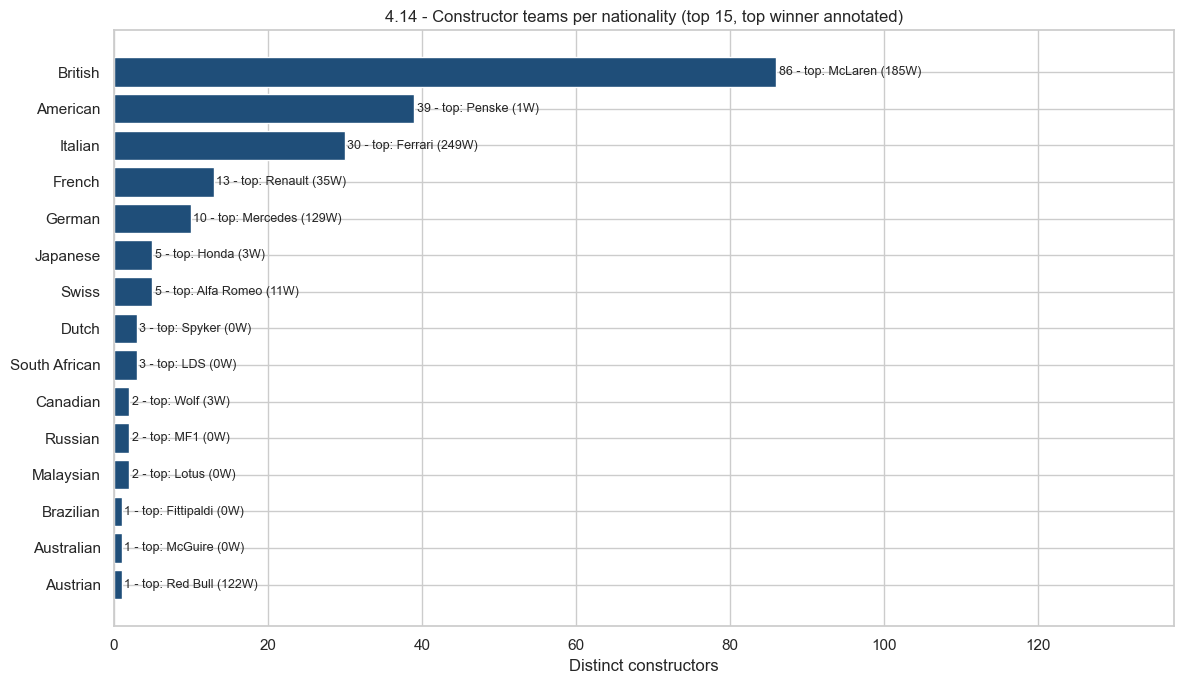

In [127]:
# Teams.ipynb renamed constructors.name -> constructors.team early on,
# so we reference 'team' here (not 'name') and reload a raw copy for the
# original-name labels in the printed table.
constructors_raw = pd.read_csv('excel/constructors.csv')
indy_ids = set(constructors_raw['constructorId']) - set(constructors['constructorId'])
constructors_raw = constructors_raw[~constructors_raw['constructorId'].isin(indy_ids)]

nat_counts = (
    constructors.groupby('nationality')['constructorId']
                .nunique()
                .reset_index(name='n_constructors')
                .sort_values('n_constructors', ascending=False)
                .head(15)
)

wins = (
    results[results['positionOrder'] == 1]
           .groupby('constructorId').size()
           .reset_index(name='wins')
)
constructors_with_wins = (
    constructors.merge(wins, on='constructorId', how='left')
                .fillna({'wins': 0})
)
constructors_with_wins['wins'] = constructors_with_wins['wins'].astype(int)

top_per_country = (
    constructors_with_wins.sort_values('wins', ascending=False)
                          .groupby('nationality')
                          .first()
                          .reset_index()[['nationality', 'team', 'wins']]
                          .rename(columns={'team': 'top_constructor',
                                           'wins': 'top_wins'})
)

table = nat_counts.merge(top_per_country, on='nationality', how='left')
print(table.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
y = range(len(table))
bars = ax.barh(y, table['n_constructors'], color='#1F4E79')
ax.set_yticks(list(y))
ax.set_yticklabels(table['nationality'])
ax.invert_yaxis()
ax.set_xlabel('Distinct constructors')
ax.set_title('4.14 - Constructor teams per nationality (top 15, top winner annotated)')

for bar, n, top, w in zip(bars, table['n_constructors'],
                          table['top_constructor'], table['top_wins']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{n} - top: {top} ({int(w)}W)",
            va='center', fontsize=9)

ax.set_xlim(0, table['n_constructors'].max() * 1.6)
plt.tight_layout()
show_and_save('4.14_constructors_per_nationality.png')


---
## Key insights from this notebook

After running everything, the takeaways:

1. **Ferrari dominates the all-time totals** (4.2, 4.3, 4.5, 4.10) because they've been in every season since 1950 — longevity matters as much as raw competitiveness.

2. **The top-team-per-season chart (4.1)** is a good era summary on its own — early Ferrari/Alfa in the 50s, late-70s Lotus (5 of 5 wins 1976–78), McLaren–Williams duopoly 80s/90s, **Ferrari 2000–2007** (8 of 10 in the decade), Red Bull early 2010s, **Mercedes 2014–2020** (7 straight years), Red Bull again 2022–24.

3. **Wire-to-wire constructor seasons (4.6) are more common than you'd expect — 23 of 67 seasons since 1958 (34 %)** had the same team lead the standings after every race. The bias is heavily toward modern eras: 9 of the 23 happened in 2009–2023 alone (Brawn, Red Bull, Mercedes, Red Bull again). Under stable regulations, wire-to-wire is the *default* outcome of a dominant car, not the exception.

4. **Year-over-year jumps (4.8)** are a useful "team turnaround" indicator — they catch the moments when a regulations change or a key hire flipped a team's fortunes.

5. **Head-to-head teammate records (4.12, 4.13)** are noisier than they look — sample sizes vary, and a "dominant" teammate often had a faster car for *part* of the partnership but not all of it.